# How to Read the Tables

In [63]:
import sqlite3
import pandas as pd

# Paths to CSV files (replace with your paths)
batting_csv = "/kaggle/input/datasets/dalyas/lahman-baseball-database/lahman_1871-2024_csv/Batting.csv"
fielding_csv = "/kaggle/input/datasets/dalyas/lahman-baseball-database/lahman_1871-2024_csv/Fielding.csv"
people_csv = "/kaggle/input/datasets/dalyas/lahman-baseball-database/lahman_1871-2024_csv/People.csv"

# 1. Read CSVs into pandas DataFrames
batting = pd.read_csv(batting_csv)
fielding = pd.read_csv(fielding_csv)
people = pd.read_csv(people_csv)

# 2. Connect to an in-memory SQLite database
conn = sqlite3.connect(":memory:") # use ":memory:" for temporary DB

# 3. Load DataFrames into SQLite as tables
batting.to_sql("Batting", conn, index=False, if_exists="replace")
fielding.to_sql("Fielding", conn, index=False, if_exists="replace")
people.to_sql("People", conn, index=False, if_exists="replace")

21271

In [64]:
batting.head(3)

,playerID,yearID,stint,teamID,lgID,G,G_batting,AB,R,H,...,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP,G_old
0,aardsda01,2004,1,SFN,NL,11,NaN,0,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,aardsda01,2006,1,CHN,NL,45,NaN,2,0,0,...,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0,0.0,NaN
2,aardsda01,2007,1,CHA,AL,25,NaN,0,0,0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [65]:
fielding.head(3)

,playerID,yearID,stint,teamID,lgID,POS,G,GS,InnOuts,PO,A,E,DP,PB,WP,SB,CS,ZR
0,aardsda01,2004,1,SFN,NL,P,11,0.0,32.0,0,0,0.0,0,NaN,NaN,NaN,NaN,NaN
1,aardsda01,2006,1,CHN,NL,P,45,0.0,159.0,1,5,0.0,1,NaN,NaN,NaN,NaN,NaN
2,aardsda01,2007,1,CHA,AL,P,25,0.0,97.0,2,4,1.0,0,NaN,NaN,NaN,NaN,NaN


In [66]:
fielding['POS'].unique()

array(['P', 'OF', '2B', '3B', '1B', 'SS', 'C'], dtype=object)

In [67]:
people.head(3)

,ID,playerID,birthYear,birthMonth,birthDay,birthCity,birthCountry,birthState,deathYear,deathMonth,...,nameLast,nameGiven,weight,height,bats,throws,debut,bbrefID,finalGame,retroID
0,1,aardsda01,1981.0,12.0,27.0,Denver,USA,CO,NaN,NaN,...,Aardsma,David Allan,215.0,75.0,R,R,2004-04-06,aardsda01,2015-08-23,aardd001
1,2,aaronha01,1934.0,2.0,5.0,Mobile,USA,AL,2021.0,1.0,...,Aaron,Henry Louis,180.0,72.0,R,R,1954-04-13,aaronha01,1976-10-03,aaroh101
2,3,aaronto01,1939.0,8.0,5.0,Mobile,USA,AL,1984.0,8.0,...,Aaron,Tommie Lee,190.0,75.0,R,R,1962-04-10,aaronto01,1971-09-26,aarot101


# Join Filtered Batting and Fielding Tables

In [68]:
joined_table = pd.read_sql_query("""
with Filtered_Batting as
(select
playerID, yearID, AB, H
from Batting
where yearID >= 1980 and AB >= 100)

, Filtered_Fielding as
(select
playerID, yearID, POS
from Fielding
where POS <> 'P' and yearID >= 1980)

select a.*, b.POS from
Filtered_Batting a
join
Filtered_Fielding b on (a.playerID = b.playerID and a.yearID = b.yearID)
""", conn)

joined_table.to_sql("JoinedTable", conn, index=False, if_exists="replace")

33693

In [69]:
joined_table.head(3)

,playerID,yearID,AB,H,POS
0,abbotje01,1998,244,68,OF
1,abbotje01,2000,215,59,OF
2,abbotku01,1994,345,86,SS


# Get Batting Average for Each Person (One-Way ANOVA)

In [70]:
table1 = pd.read_sql_query("""
with BattingAvgTable as
(select playerID, 1.00*sum(H)/sum(AB) Batting_Avg
from JoinedTable
group by playerID)

select a.*, b.bats from BattingAvgTable a join People b using(playerID)
""", conn)

In [71]:
table1.head(3)

,playerID,Batting_Avg,bats
0,abbotje01,0.276688,R
1,abbotku01,0.259225,R
2,abercre01,0.211765,R


# Distribution of Handedness

In [72]:
import pandas as pd
table1[['Batting_Avg', 'bats']].dropna().groupby('bats').size()

bats
B     442
L     985
R    1751
dtype: int64

# Run One-Way ANOVA

In [73]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit model
model = ols('Batting_Avg ~ C(bats)', data=table1).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

            sum_sq      df         F   PR(>F)
C(bats)   0.008547     2.0  5.998933  0.00251
Residual  2.261902  3175.0       NaN      NaN


# Diagnostic Plots

## Q-Q Plot (Check Normality of Residuals)

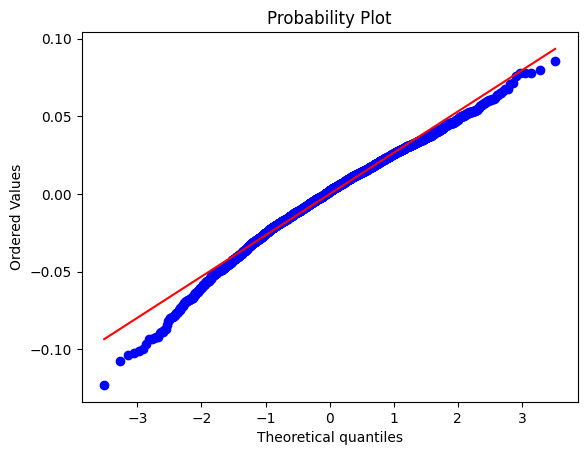

In [74]:
import matplotlib.pyplot as plt
import scipy.stats as stats

stats.probplot(model.resid, plot=plt)
plt.savefig("qqplot.png", dpi=300, bbox_inches='tight')
plt.show()

## Boxplot (Compare Group Distributions)

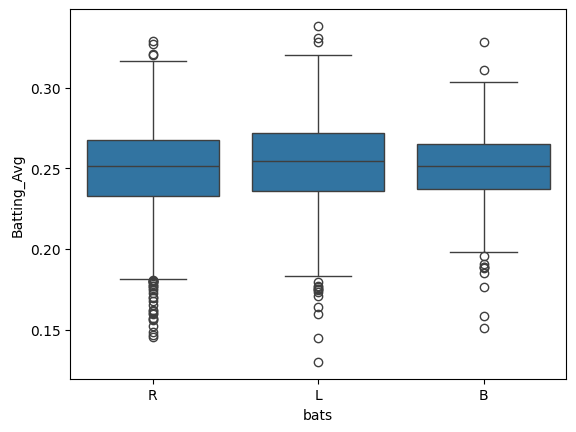

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='bats', y='Batting_Avg', data=table1)
plt.savefig("boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

# Post-Hoc Analysis: Tukey HSD

In [76]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
endog=table1['Batting_Avg'],
groups=table1['bats'],
alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     B      L   0.0021 0.3577 -0.0015  0.0057  False
     B      R  -0.0016 0.5043 -0.0049  0.0017  False
     L      R  -0.0037 0.0016 -0.0062 -0.0012   True
----------------------------------------------------


# Creating Table for Two-Way ANOVA

In [77]:
table2 = pd.read_sql_query("""
with BattingAvgTable as
(select playerID, 1.00*sum(H)/sum(AB) Batting_Avg
from JoinedTable
group by playerID)

select
a.*, b.bats, b.birthYear
, case 
when b.birthYear < 1980 then 'Before 1980'
else 'After 1980' end as Era

from BattingAvgTable a join People b using(playerID)
""", conn)

In [78]:
table2.head(3)

,playerID,Batting_Avg,bats,birthYear,Era
0,abbotje01,0.276688,R,1972.0,Before 1980
1,abbotku01,0.259225,R,1969.0,Before 1980
2,abercre01,0.211765,R,1980.0,After 1980


# Run Two-Way ANOVA

In [79]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit two-way ANOVA model: main effects + interaction
model = ols('Batting_Avg ~ C(bats) + C(Era) + C(bats):C(Era)', data=table2).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                  sum_sq      df           F        PR(>F)
C(bats)         0.011665     2.0    8.642659  1.806054e-04
C(Era)          0.111103     1.0  164.633357  8.896059e-37
C(bats):C(Era)  0.010176     2.0    7.539792  5.410890e-04
Residual        2.140623  3172.0         NaN           NaN


# Post-Hoc Analysis: Batting Handedness (Tukey HSD)

In [80]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_bats = pairwise_tukeyhsd(endog=table2[
'Batting_Avg'],
groups=table2['bats'],
alpha=0.05)

print(tukey_bats)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     B      L   0.0021 0.3577 -0.0015  0.0057  False
     B      R  -0.0016 0.5043 -0.0049  0.0017  False
     L      R  -0.0037 0.0016 -0.0062 -0.0012   True
----------------------------------------------------


# Post-Hoc Analysis: Birth Era (Tukey HSD)

In [81]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_era = pairwise_tukeyhsd(endog=table2['Batting_Avg'],
groups=table2['Era'],
alpha=0.05)
                             
print(tukey_era)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1      group2   meandiff p-adj lower  upper  reject
----------------------------------------------------------
After 1980 Before 1980   0.0117   0.0 0.0099 0.0136   True
----------------------------------------------------------


# Post-Hoc Analysis: Interaction Effect (Tukey HSD)

In [82]:
table2.head(3)

,playerID,Batting_Avg,bats,birthYear,Era
0,abbotje01,0.276688,R,1972.0,Before 1980
1,abbotku01,0.259225,R,1969.0,Before 1980
2,abercre01,0.211765,R,1980.0,After 1980


In [83]:
table2['bats_Era'] = table2['bats']+ '_' + table2['Era']

table2.head(3)

,playerID,Batting_Avg,bats,birthYear,Era,bats_Era
0,abbotje01,0.276688,R,1972.0,Before 1980,R_Before 1980
1,abbotku01,0.259225,R,1969.0,Before 1980,R_Before 1980
2,abercre01,0.211765,R,1980.0,After 1980,R_After 1980


In [84]:
tukey_inter = pairwise_tukeyhsd(endog=table2['Batting_Avg'], groups=table2['bats_Era'],
alpha=0.05)

print(tukey_inter)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
 B_After 1980 B_Before 1980   0.0132    0.0   0.006  0.0204   True
 B_After 1980  L_After 1980   0.0014 0.9913 -0.0052  0.0079  False
 B_After 1980 L_Before 1980   0.0182    0.0  0.0117  0.0247   True
 B_After 1980  R_After 1980   0.0014 0.9894 -0.0049  0.0076  False
 B_After 1980 R_Before 1980   0.0102    0.0  0.0041  0.0163   True
B_Before 1980  L_After 1980  -0.0118    0.0 -0.0175 -0.0061   True
B_Before 1980 L_Before 1980    0.005 0.1083 -0.0006  0.0106  False
B_Before 1980  R_After 1980  -0.0118    0.0 -0.0171 -0.0065   True
B_Before 1980 R_Before 1980   -0.003 0.5548 -0.0081  0.0021  False
 L_After 1980 L_Before 1980   0.0168    0.0  0.0121  0.0215   True
 L_After 1980  R_After 1980     -0.0    1.0 -0.0043  0.0043  False
 L_After 1980 R_Before 1980   0.0088    0.0  0.0047  0.0129   

# Visualizing the Interaction Effect

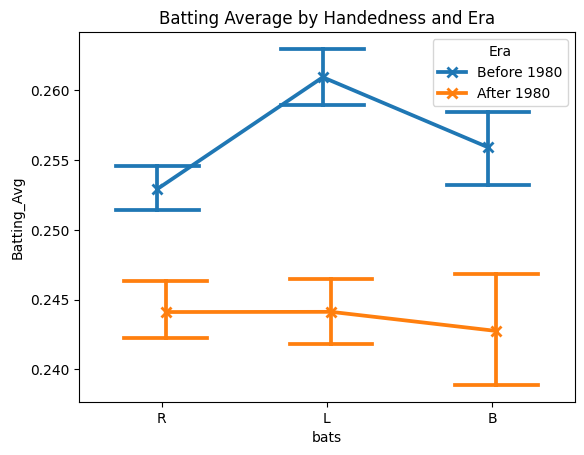

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pointplot(x='bats', y='Batting_Avg',
hue='Era', data=table2, dodge=True,
markers='x', capsize=0.5)

plt.title('Batting Average by Handedness and Era')
plt.show()